# 🦴 Pipeline Híbrido: YOLOv8 + MedSAM — Segmentación Vertebral

### Flujo:
```
Imagen → YOLOv8 (detecta cada vértebra + clase) → MedSAM (segmenta dentro del bbox)
```

### ¿Por qué híbrido?
| Problema | Quién lo resuelve |
|---|---|
| Identificar cuál es T2 y cuál T3 | **YOLOv8** (detección por clase) |
| Segmentación precisa del borde | **MedSAM** (foundation model médico) |
| Evitar fusión de vértebras vecinas | **YOLOv8** genera bboxes ajustados |

### Archivos necesarios:
| Archivo | Uso |
|---|---|
| `indice_dataset.csv` | Mapeo imagen ↔ máscara |
| `reporte_por_mascara_version_final.csv` | Filtrado |
| `Normal/*.jpg` + `Scoliosis/*.jpg` | Radiografías |
| `LabelMultiClass_ID_PNG/*.png` | Máscaras (GT + generación de labels YOLO) |

## 0 — Instalación y Setup

In [2]:
!pip install -q ultralytics transformers monai opencv-python-headless matplotlib scikit-learn tqdm
!pip install -q git+https://github.com/bowang-lab/MedSAM.git

import torch, os, cv2, random, re, shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.patches import Patch
from pathlib import Path
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

print(f'PyTorch: {torch.__version__}')
if torch.cuda.is_available():
    print(f'GPU:     {torch.cuda.get_device_name(0)}')
    print(f'VRAM:    {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
    DEVICE = torch.device('cuda')
else:
    print('⚠️ No GPU'); DEVICE = torch.device('cpu')

  Preparing metadata (setup.py) ... done
PyTorch: 2.10.0+cu128
GPU:     Tesla T4
VRAM:    15.6 GB


In [3]:
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

DATASET_ROOT = Path('/kaggle/input/datasets/javiercamilogarcia/scoliosis-dataset')  # ← AJUSTAR
CSV_INDICE   = DATASET_ROOT / 'indice_dataset.csv'
CSV_REPORTE  = DATASET_ROOT / 'reporte_por_mascara_version_final.csv'
WORK_DIR     = Path('/kaggle/working/hybrid_pipeline')
WORK_DIR.mkdir(parents=True, exist_ok=True)

COL_GRUPO = 'grupo'
COL_IMAGE = 'ruta_radiografia'
COL_MASK  = 'ruta_mascara_multiclase_id_png'

CLASS_NAMES = ['T1','T2','T3','T4','T5','T6','T7','T8','T9','T10','T11','T12',
               'L1','L2','L3','L4','L5']
NUM_CLASSES = 17
MEDSAM_IMG_SIZE = 1024
print('✔ Configuración lista')

✔ Configuración lista


## 1 — Carga de Datos y Filtrado

In [4]:
# ── Cargar índice ──
df = pd.read_csv(CSV_INDICE)
print(f'Índice: {len(df)} imágenes')

# ── Parsear reporte (quoting complejo) ──
records = []
with open(CSV_REPORTE, 'r', encoding='utf-8') as f:
    lines = f.readlines()
for line in lines[1:]:
    line = line.strip()
    if not line: continue
    if line.startswith('"') and line.endswith('"'): line = line[1:-1]
    parts = line.split(',')
    filename = parts[0]
    rest = ','.join(parts[1:])
    cleaned = re.sub(r'"".*?""', '', rest)
    nums = re.findall(r'\d+', cleaned)
    num_vert = int(nums[-1]) if nums else 0
    records.append({'archivo_mascara': filename, 'num_vertebras': num_vert})
reporte = pd.DataFrame(records)

# ── Merge + filtrar ──
df['archivo_mascara'] = df[COL_MASK].apply(lambda x: Path(x).name if pd.notna(x) else '')
df_merged = df.merge(reporte, on='archivo_mascara', how='left')
MIN_VERT = 13
df_clean = df_merged[df_merged['num_vertebras'] >= MIN_VERT].reset_index(drop=True)

print(f'Válidas (≥{MIN_VERT}): {len(df_clean)}')
print(f'  Normal: {len(df_clean[df_clean[COL_GRUPO]=="Normal"])}')
print(f'  Scoliosis: {len(df_clean[df_clean[COL_GRUPO]=="Scoliosis"])}')

# ── Split 70/15/15 ──
train_df, temp_df = train_test_split(df_clean, test_size=0.30,
    stratify=df_clean[COL_GRUPO], random_state=SEED)
val_df, test_df = train_test_split(temp_df, test_size=0.50,
    stratify=temp_df[COL_GRUPO], random_state=SEED)
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

for name, s in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    print(f'{name:5s}: {len(s):3d} (N:{len(s[s[COL_GRUPO]=="Normal"])}, S:{len(s[s[COL_GRUPO]=="Scoliosis"])})')

Índice: 250 imágenes
Válidas (≥13): 164
  Normal: 70
  Scoliosis: 94
Train: 114 (N:49, S:65)
Val  :  25 (N:11, S:14)
Test :  25 (N:10, S:15)


## 2 — Generar Labels YOLO desde Máscaras

Convierte cada máscara `LabelMultiClass_ID_PNG` a formato YOLO bbox:
```
class_id x_center y_center width height  (todo normalizado 0-1)
```

In [5]:
YOLO_DIR = WORK_DIR / 'yolo_dataset'

# ── Crear estructura ──
for split in ['train', 'val', 'test']:
    (YOLO_DIR / 'images' / split).mkdir(parents=True, exist_ok=True)
    (YOLO_DIR / 'labels' / split).mkdir(parents=True, exist_ok=True)

def mask_to_yolo_bboxes(mask_path):
    """Convierte máscara ID_PNG a labels YOLO (0-indexed)."""
    mask = cv2.imread(str(mask_path), cv2.IMREAD_UNCHANGED)
    if mask is None: return []
    if mask.ndim == 3: mask = mask[:,:,0]
    h, w = mask.shape
    lines = []
    for cls_id in range(1, NUM_CLASSES + 1):
        binary = (mask == cls_id).astype(np.uint8)
        if binary.sum() < 50: continue
        ys, xs = np.where(binary > 0)
        x_center = (xs.min() + xs.max()) / 2 / w
        y_center = (ys.min() + ys.max()) / 2 / h
        bw = (xs.max() - xs.min()) / w
        bh = (ys.max() - ys.min()) / h
        lines.append(f'{cls_id - 1} {x_center:.6f} {y_center:.6f} {bw:.6f} {bh:.6f}')
    return lines

# ── Procesar splits ──
total_labels = 0
for split_name, split_df in [('train', train_df), ('val', val_df), ('test', test_df)]:
    count = 0
    for _, row in tqdm(split_df.iterrows(), total=len(split_df), desc=split_name):
        stem = Path(row[COL_IMAGE]).stem
        # Copiar imagen
        shutil.copy2(str(DATASET_ROOT / row[COL_IMAGE]),
                     str(YOLO_DIR / 'images' / split_name / f'{stem}.jpg'))
        # Generar labels
        lines = mask_to_yolo_bboxes(DATASET_ROOT / row[COL_MASK])
        with open(YOLO_DIR / 'labels' / split_name / f'{stem}.txt', 'w') as f:
            f.write('\n'.join(lines))
        count += 1; total_labels += len(lines)
    print(f'  {split_name}: {count} imgs')

# ── data.yaml ──
yaml_content = f"""path: {YOLO_DIR}
train: images/train
val: images/val
test: images/test

nc: {NUM_CLASSES}
names: {CLASS_NAMES}
"""
with open(YOLO_DIR / 'data.yaml', 'w') as f:
    f.write(yaml_content)

print(f'\n✔ Dataset YOLO generado: {YOLO_DIR}')
print(f'  Total bboxes generados: {total_labels}')

train: 100%|██████████| 114/114 [00:12<00:00,  9.26it/s]


  train: 114 imgs


val: 100%|██████████| 25/25 [00:03<00:00,  7.09it/s]


  val: 25 imgs


test: 100%|██████████| 25/25 [00:03<00:00,  8.15it/s]

  test: 25 imgs

✔ Dataset YOLO generado: /kaggle/working/hybrid_pipeline/yolo_dataset
  Total bboxes generados: 2599


## 3 — Entrenar YOLOv8 Detección

Se entrena YOLOv8m para **detección** (no segmentación).
Solo necesita aprender a localizar e identificar cada vértebra.

In [6]:
from ultralytics import YOLO

model_yolo = YOLO('yolov8m.pt')  # medium

results = model_yolo.train(
    data=str(YOLO_DIR / 'data.yaml'),
    epochs=50,
    imgsz=640,
    batch=8,
    patience=10,
    name='vertebra_detect',
    project=str(WORK_DIR / 'yolo_runs'),
    save=True,
    plots=True,
    seed=SEED
)
print('✔ YOLOv8 entrenado')

# ── Mostrar métricas ──
metrics = model_yolo.val()
print(f'\nmAP50:    {metrics.box.map50:.4f}')
print(f'mAP50-95: {metrics.box.map:.4f}')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.51 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/hybrid_pipeline/yolo_dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015,

## 4 — Cargar MedSAM + Pesos Fine-Tuned

In [7]:
from transformers import SamModel, SamProcessor
from huggingface_hub import hf_hub_download

# ── Cargar MedSAM base ──
processor = SamProcessor.from_pretrained('wanglab/medsam-vit-base')
model_sam = SamModel.from_pretrained('wanglab/medsam-vit-base').to(DEVICE)

# ── Cargar pesos fine-tuned desde HuggingFace ──
wp = hf_hub_download(
    repo_id='javiercamilogarcia/submissions',
    filename='medsam_spine_finetuned.pth',  # pesos v2
    repo_type='dataset'
)
model_sam.mask_decoder.load_state_dict(torch.load(wp, map_location=DEVICE))
model_sam.eval()
print('✔ MedSAM cargado con pesos fine-tuned')

preprocessor_config.json:   0%|          | 0.00/466 [00:00<?, ?B/s]

The image processor of type `SamImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/375M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/315 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared_image_embedding.positional_embedding to prompt_encoder.shared_embedding.positional_embedding, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


model.safetensors:   0%|          | 0.00/375M [00:00<?, ?B/s]

medsam_spine_finetuned.pth:   0%|          | 0.00/16.3M [00:00<?, ?B/s]

✔ MedSAM cargado con pesos fine-tuned


## 5 — Pipeline Híbrido: YOLOv8 → MedSAM

```
Imagen ──→ YOLOv8 ──→ [(T1, bbox), (T2, bbox), ...] ──→ MedSAM ──→ Máscaras por vértebra
             │                                                │
      Identifica y localiza                          Segmenta con precisión
```

In [8]:
def load_image_and_mask(row):
    img = cv2.imread(str(DATASET_ROOT / row[COL_IMAGE]))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    mask = cv2.imread(str(DATASET_ROOT / row[COL_MASK]), cv2.IMREAD_UNCHANGED)
    if mask.ndim == 3: mask = mask[:,:,0]
    return img, mask

@torch.no_grad()
def get_image_embedding(model, processor, image):
    inputs = processor(images=image, return_tensors='pt').to(DEVICE)
    return model.get_image_embeddings(inputs['pixel_values']), inputs

def postprocess_prediction(pred, bbox):
    x_min, y_min, x_max, y_max = bbox
    cleaned = np.zeros_like(pred)
    cleaned[y_min:y_max, x_min:x_max] = pred[y_min:y_max, x_min:x_max]
    return cleaned

@torch.no_grad()
def hybrid_predict(image, model_yolo, model_sam, processor, conf=0.25):
    """
    Pipeline híbrido:
    1. YOLOv8 detecta vértebras con bboxes por clase
    2. MedSAM segmenta cada vértebra dentro de su bbox
    """
    h_orig, w_orig = image.shape[:2]

    # 1. YOLOv8 detecta
    det = model_yolo(image, conf=conf, verbose=False)[0]

    # 2. Preparar imagen 1024x1024 para MedSAM
    img_1024 = cv2.resize(image, (1024, 1024), interpolation=cv2.INTER_LINEAR)
    emb, _ = get_image_embedding(model_sam, processor, img_1024)

    predictions = {}
    sx, sy = 1024 / w_orig, 1024 / h_orig

    for box in det.boxes:
        cls_id = int(box.cls[0])       # 0-indexed
        cls_name = CLASS_NAMES[cls_id]
        conf_val = float(box.conf[0])

        # Si ya hay una predicción con mayor confianza para esta clase, saltar
        if cls_name in predictions and predictions[cls_name]['conf'] >= conf_val:
            continue

        # Escalar bbox a 1024x1024
        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
        bbox_1024 = [int(x1*sx), int(y1*sy), int(x2*sx), int(y2*sy)]
        # Clamp
        bbox_1024 = [max(0, bbox_1024[0]), max(0, bbox_1024[1]),
                     min(1024, bbox_1024[2]), min(1024, bbox_1024[3])]

        # 3. MedSAM segmenta
        sam_in = processor(images=img_1024, input_boxes=[[bbox_1024]],
                           return_tensors='pt').to(DEVICE)
        out = model_sam(image_embeddings=emb,
                        input_boxes=sam_in['input_boxes'],
                        multimask_output=False)
        masks = processor.image_processor.post_process_masks(
            out.pred_masks.cpu(), sam_in['original_sizes'].cpu(),
            sam_in['reshaped_input_sizes'].cpu())
        pred = (masks[0].squeeze().numpy() > 0.5).astype(np.uint8)
        pred = postprocess_prediction(pred, bbox_1024)

        predictions[cls_name] = {
            'mask': pred,
            'bbox': bbox_1024,
            'conf': conf_val
        }

    return predictions

print('✔ Pipeline híbrido definido')

✔ Pipeline híbrido definido


## 6 — Evaluación del Pipeline Híbrido

In [9]:
def compute_dice(pred, gt):
    p, g = pred.astype(bool), gt.astype(bool)
    inter = np.logical_and(p, g).sum()
    return 1.0 if p.sum()+g.sum()==0 else 2.0*inter/(p.sum()+g.sum())

def compute_iou(pred, gt):
    p, g = pred.astype(bool), gt.astype(bool)
    inter = np.logical_and(p, g).sum()
    union = np.logical_or(p, g).sum()
    return 1.0 if union==0 else inter/union

def evaluate_hybrid(model_yolo, model_sam, processor, eval_df, conf=0.25):
    """Evalúa pipeline híbrido contra ground truth."""
    results = {n: {'dice':[], 'iou':[]} for n in CLASS_NAMES}
    detected_count = 0
    total_gt_count = 0

    for _, row in tqdm(eval_df.iterrows(), total=len(eval_df), desc='Evaluando'):
        img, mask = load_image_and_mask(row)
        mask_1024 = cv2.resize(mask, (1024, 1024), interpolation=cv2.INTER_NEAREST)

        # Pipeline híbrido
        preds = hybrid_predict(img, model_yolo, model_sam, processor, conf)

        for cls_id in range(1, NUM_CLASSES + 1):
            cn = CLASS_NAMES[cls_id - 1]
            gt_binary = (mask_1024 == cls_id).astype(np.uint8)
            if gt_binary.sum() < 50: continue
            total_gt_count += 1

            if cn in preds:
                detected_count += 1
                pred_mask = preds[cn]['mask']
                if pred_mask.shape != gt_binary.shape:
                    pred_mask = cv2.resize(pred_mask, (gt_binary.shape[1], gt_binary.shape[0]),
                                          interpolation=cv2.INTER_NEAREST)
                results[cn]['dice'].append(compute_dice(pred_mask, gt_binary))
                results[cn]['iou'].append(compute_iou(pred_mask, gt_binary))
            else:
                # Vértebra no detectada → Dice=0
                results[cn]['dice'].append(0.0)
                results[cn]['iou'].append(0.0)

    summary = {}
    for n in CLASS_NAMES:
        if results[n]['dice']:
            summary[n] = {'dice':np.mean(results[n]['dice']),
                          'iou':np.mean(results[n]['iou']),
                          'n':len(results[n]['dice'])}
    ad = [v['dice'] for v in summary.values()]
    ai = [v['iou'] for v in summary.values()]
    summary['MEAN'] = {'dice':np.mean(ad), 'iou':np.mean(ai),
                       'n':sum(v['n'] for v in summary.values())}

    detection_rate = detected_count / total_gt_count * 100 if total_gt_count > 0 else 0
    print(f'\n  Tasa de detección: {detected_count}/{total_gt_count} ({detection_rate:.1f}%)')
    return summary

def print_results(summary, title='Resultados'):
    print(f'\n{"="*45}')
    print(f'  {title}')
    print(f'{"="*45}')
    print(f'{"Clase":>8} {"Dice":>8} {"IoU":>8} {"N":>6}')
    print(f'{"-"*34}')
    for n in CLASS_NAMES:
        if n in summary:
            s=summary[n]; print(f'{n:>8} {s["dice"]:8.4f} {s["iou"]:8.4f} {s["n"]:6d}')
    print(f'{"-"*34}')
    m=summary['MEAN']; print(f'{"MEAN":>8} {m["dice"]:8.4f} {m["iou"]:8.4f} {m["n"]:6d}')

# ── Cargar mejor modelo YOLOv8 ──
best_yolo = YOLO(str(WORK_DIR / 'yolo_runs' / 'vertebra_detect' / 'weights' / 'best.pt'))
print('✔ Mejor YOLOv8 cargado')

# ── Evaluar en test ──
print('\nEvaluando pipeline híbrido en test...')
hybrid_results = evaluate_hybrid(best_yolo, model_sam, processor, test_df)
print_results(hybrid_results, 'Pipeline Híbrido — Test')

✔ Mejor YOLOv8 cargado

Evaluando pipeline híbrido en test...



Evaluando: 100%|██████████| 25/25 [00:25<00:00,  1.01s/it]


  Tasa de detección: 346/388 (89.2%)

  Pipeline Híbrido — Test
   Clase     Dice      IoU      N
----------------------------------
      T1   0.6023   0.5207     25
      T2   0.5239   0.4363     25
      T3   0.4564   0.3901     25
      T4   0.4550   0.3872     25
      T5   0.3530   0.3008     25
      T6   0.2962   0.2529     25
      T7   0.2996   0.2595     24
      T8   0.2773   0.2447     25
      T9   0.2440   0.2171     25
     T10   0.1844   0.1695     25
     T11   0.3607   0.3283     25
     T12   0.3966   0.3621     25
      L1   0.4492   0.4085     24
      L2   0.3638   0.3284     22
      L3   0.4284   0.3934     17
      L4   0.2617   0.2257     16
      L5   0.4491   0.3634     10
----------------------------------
    MEAN   0.3766   0.3287    388


## 7 — Visualización del Pipeline Híbrido

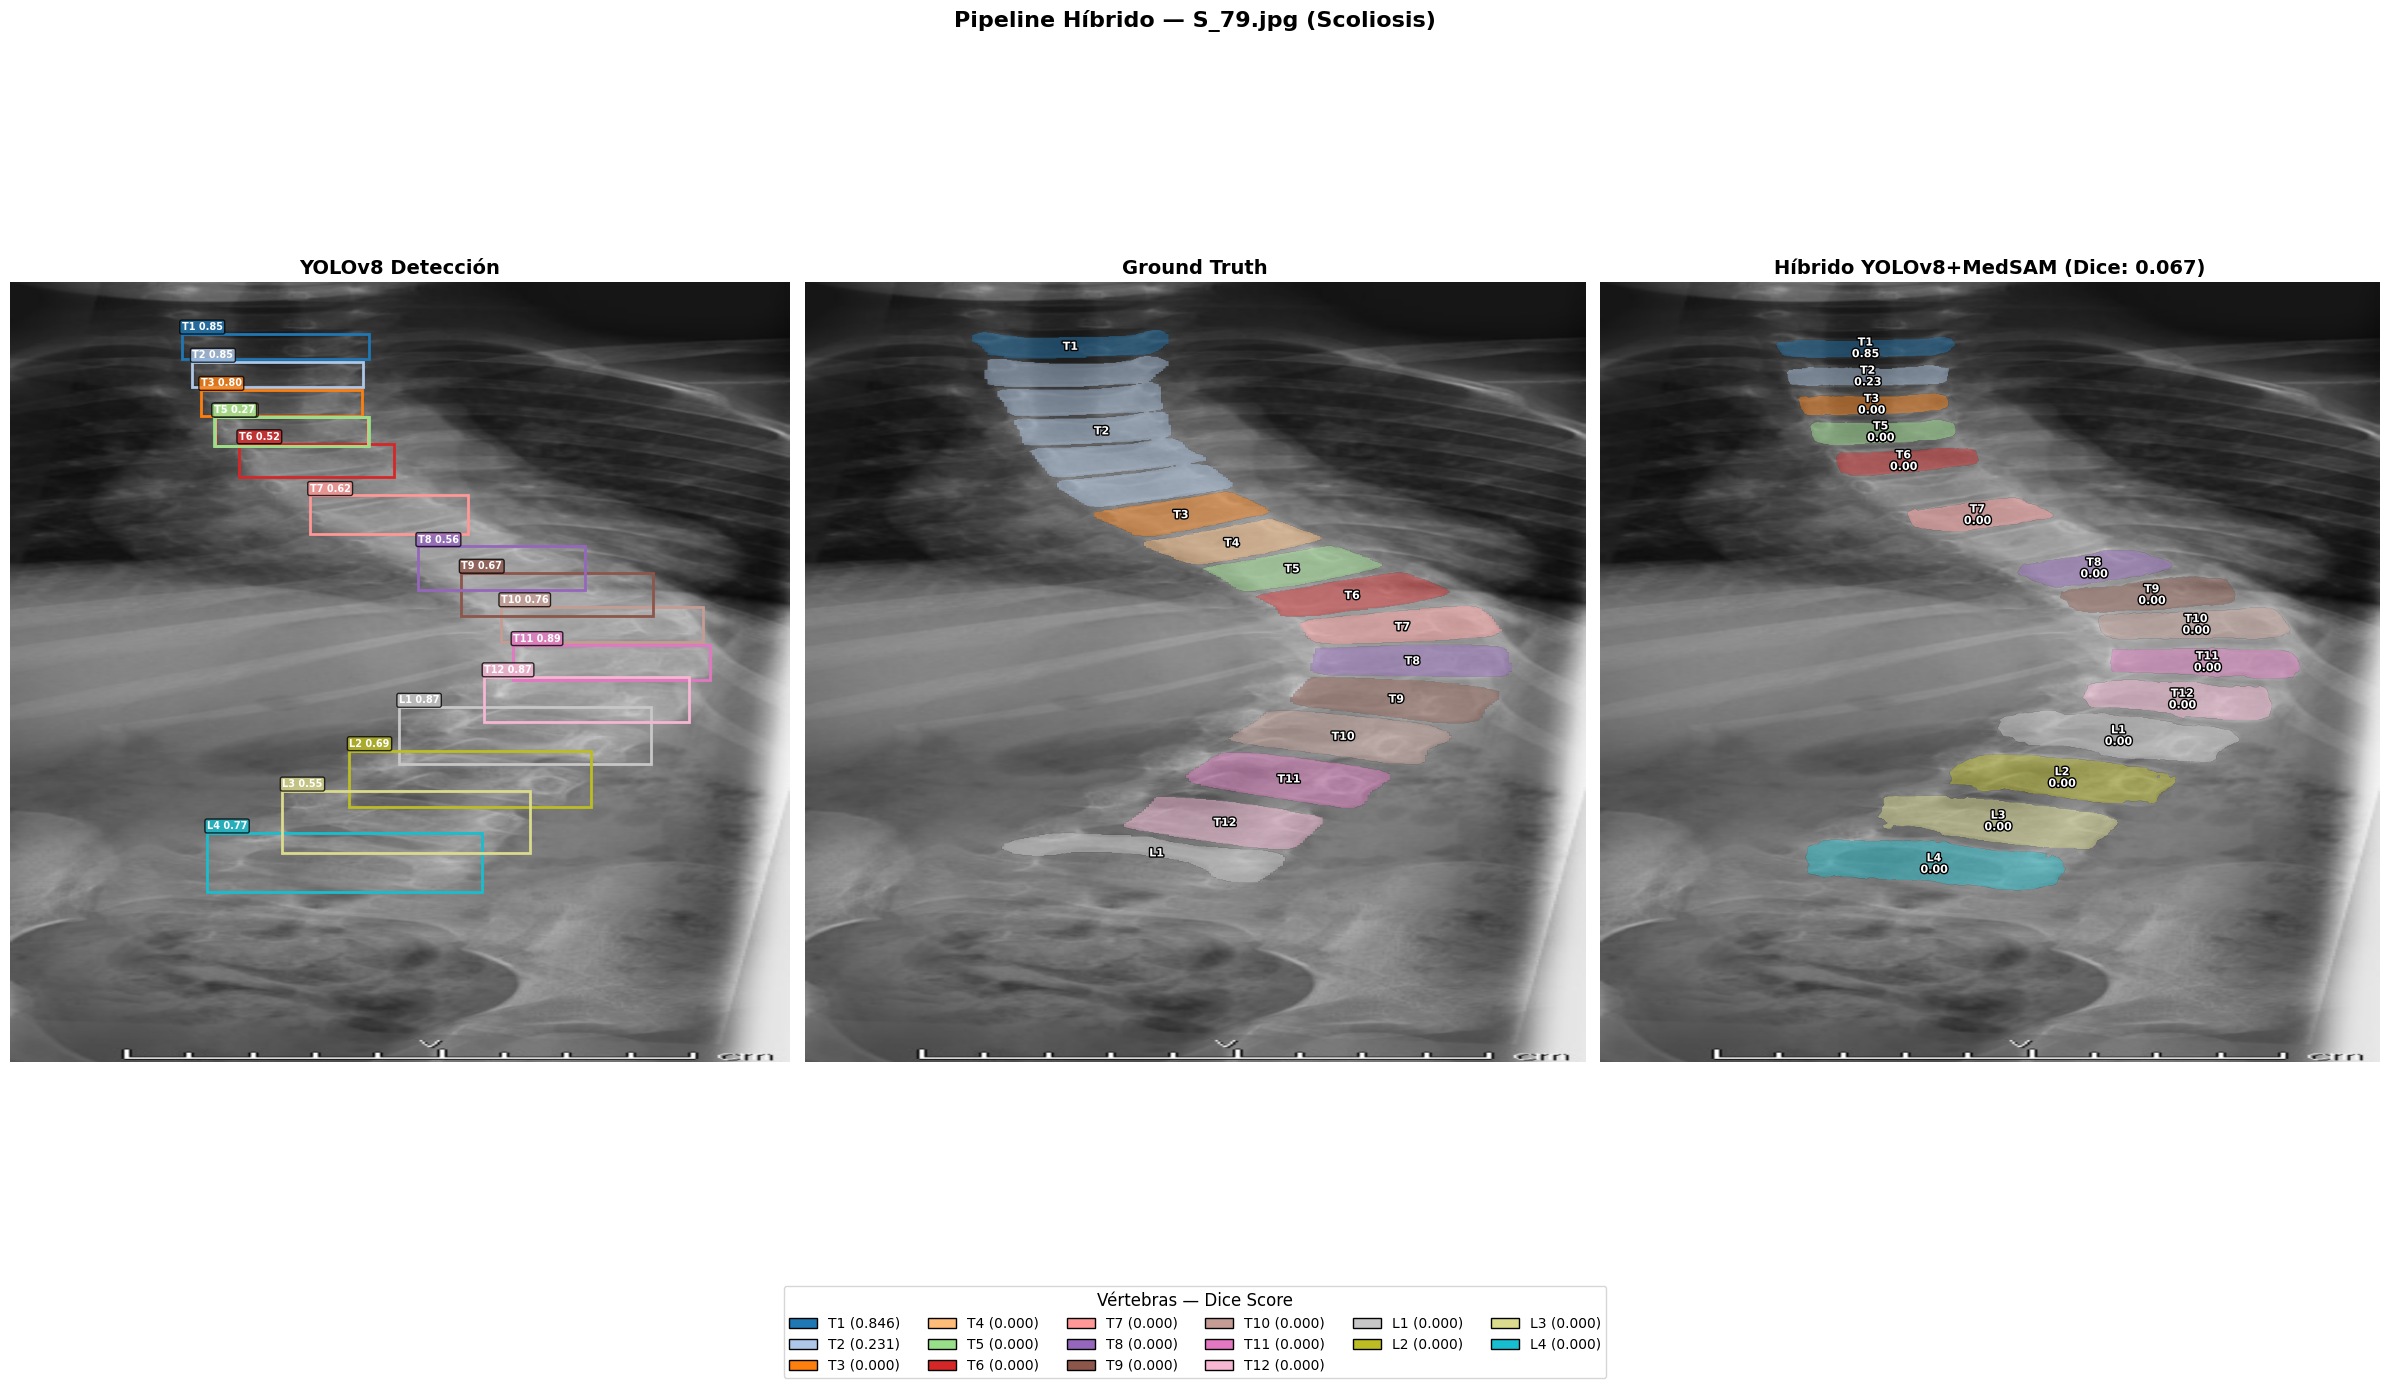


  Dice — S_79.jpg (Scoliosis)
   T11: 0.0000 
    L1: 0.0000 
   T12: 0.0000 
    T2: 0.2315 ████
    T1: 0.8459 ████████████████
    T3: 0.0000 
    L4: 0.0000 
   T10: 0.0000 
    L2: 0.0000 
    T9: 0.0000 
    T7: 0.0000 
    T8: 0.0000 
    L3: 0.0000 
    T6: 0.0000 
    T4: 0.0000 
    T5: 0.0000 
────────────────────────────────────────
  MEAN: 0.0673


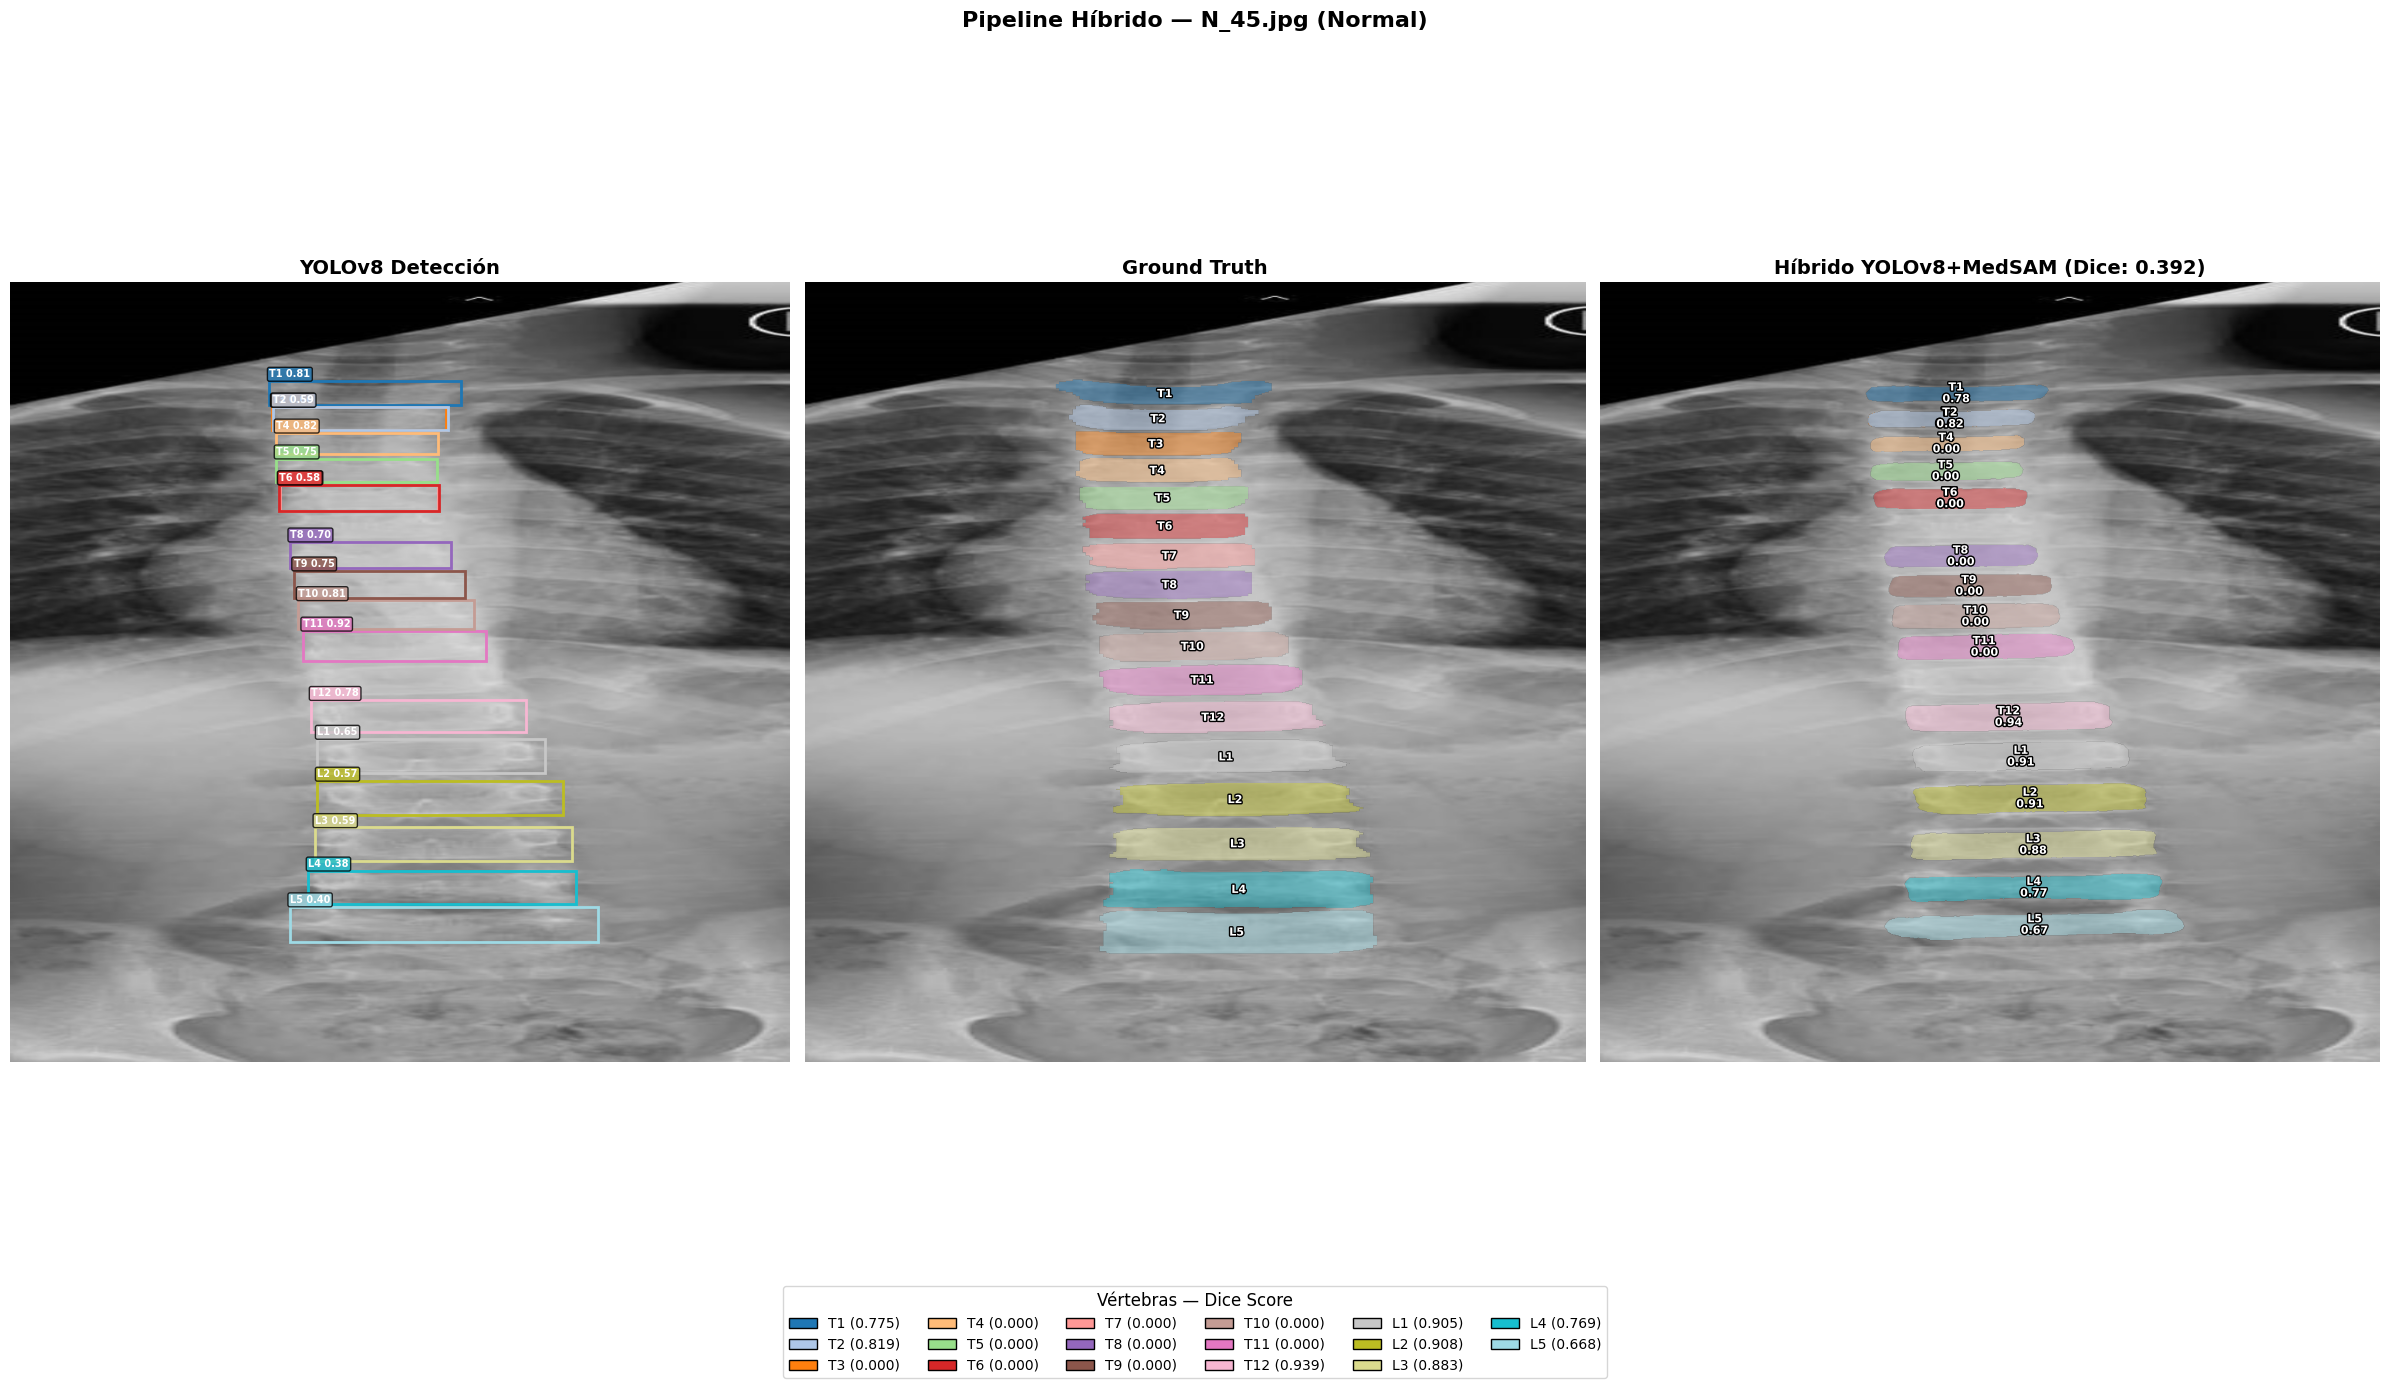


  Dice — N_45.jpg (Normal)
   T11: 0.0000 
    T4: 0.0000 
    T1: 0.7752 ███████████████
   T10: 0.0000 
   T12: 0.9390 ██████████████████
    T9: 0.0000 
    T5: 0.0000 
    T8: 0.0000 
    T3: 0.0000 
    L1: 0.9054 ██████████████████
    T7: 0.0000 
    T2: 0.8194 ████████████████
    L3: 0.8830 █████████████████
    T6: 0.0000 
    L2: 0.9075 ██████████████████
    L5: 0.6681 █████████████
    L4: 0.7688 ███████████████
────────────────────────────────────────
  MEAN: 0.3921


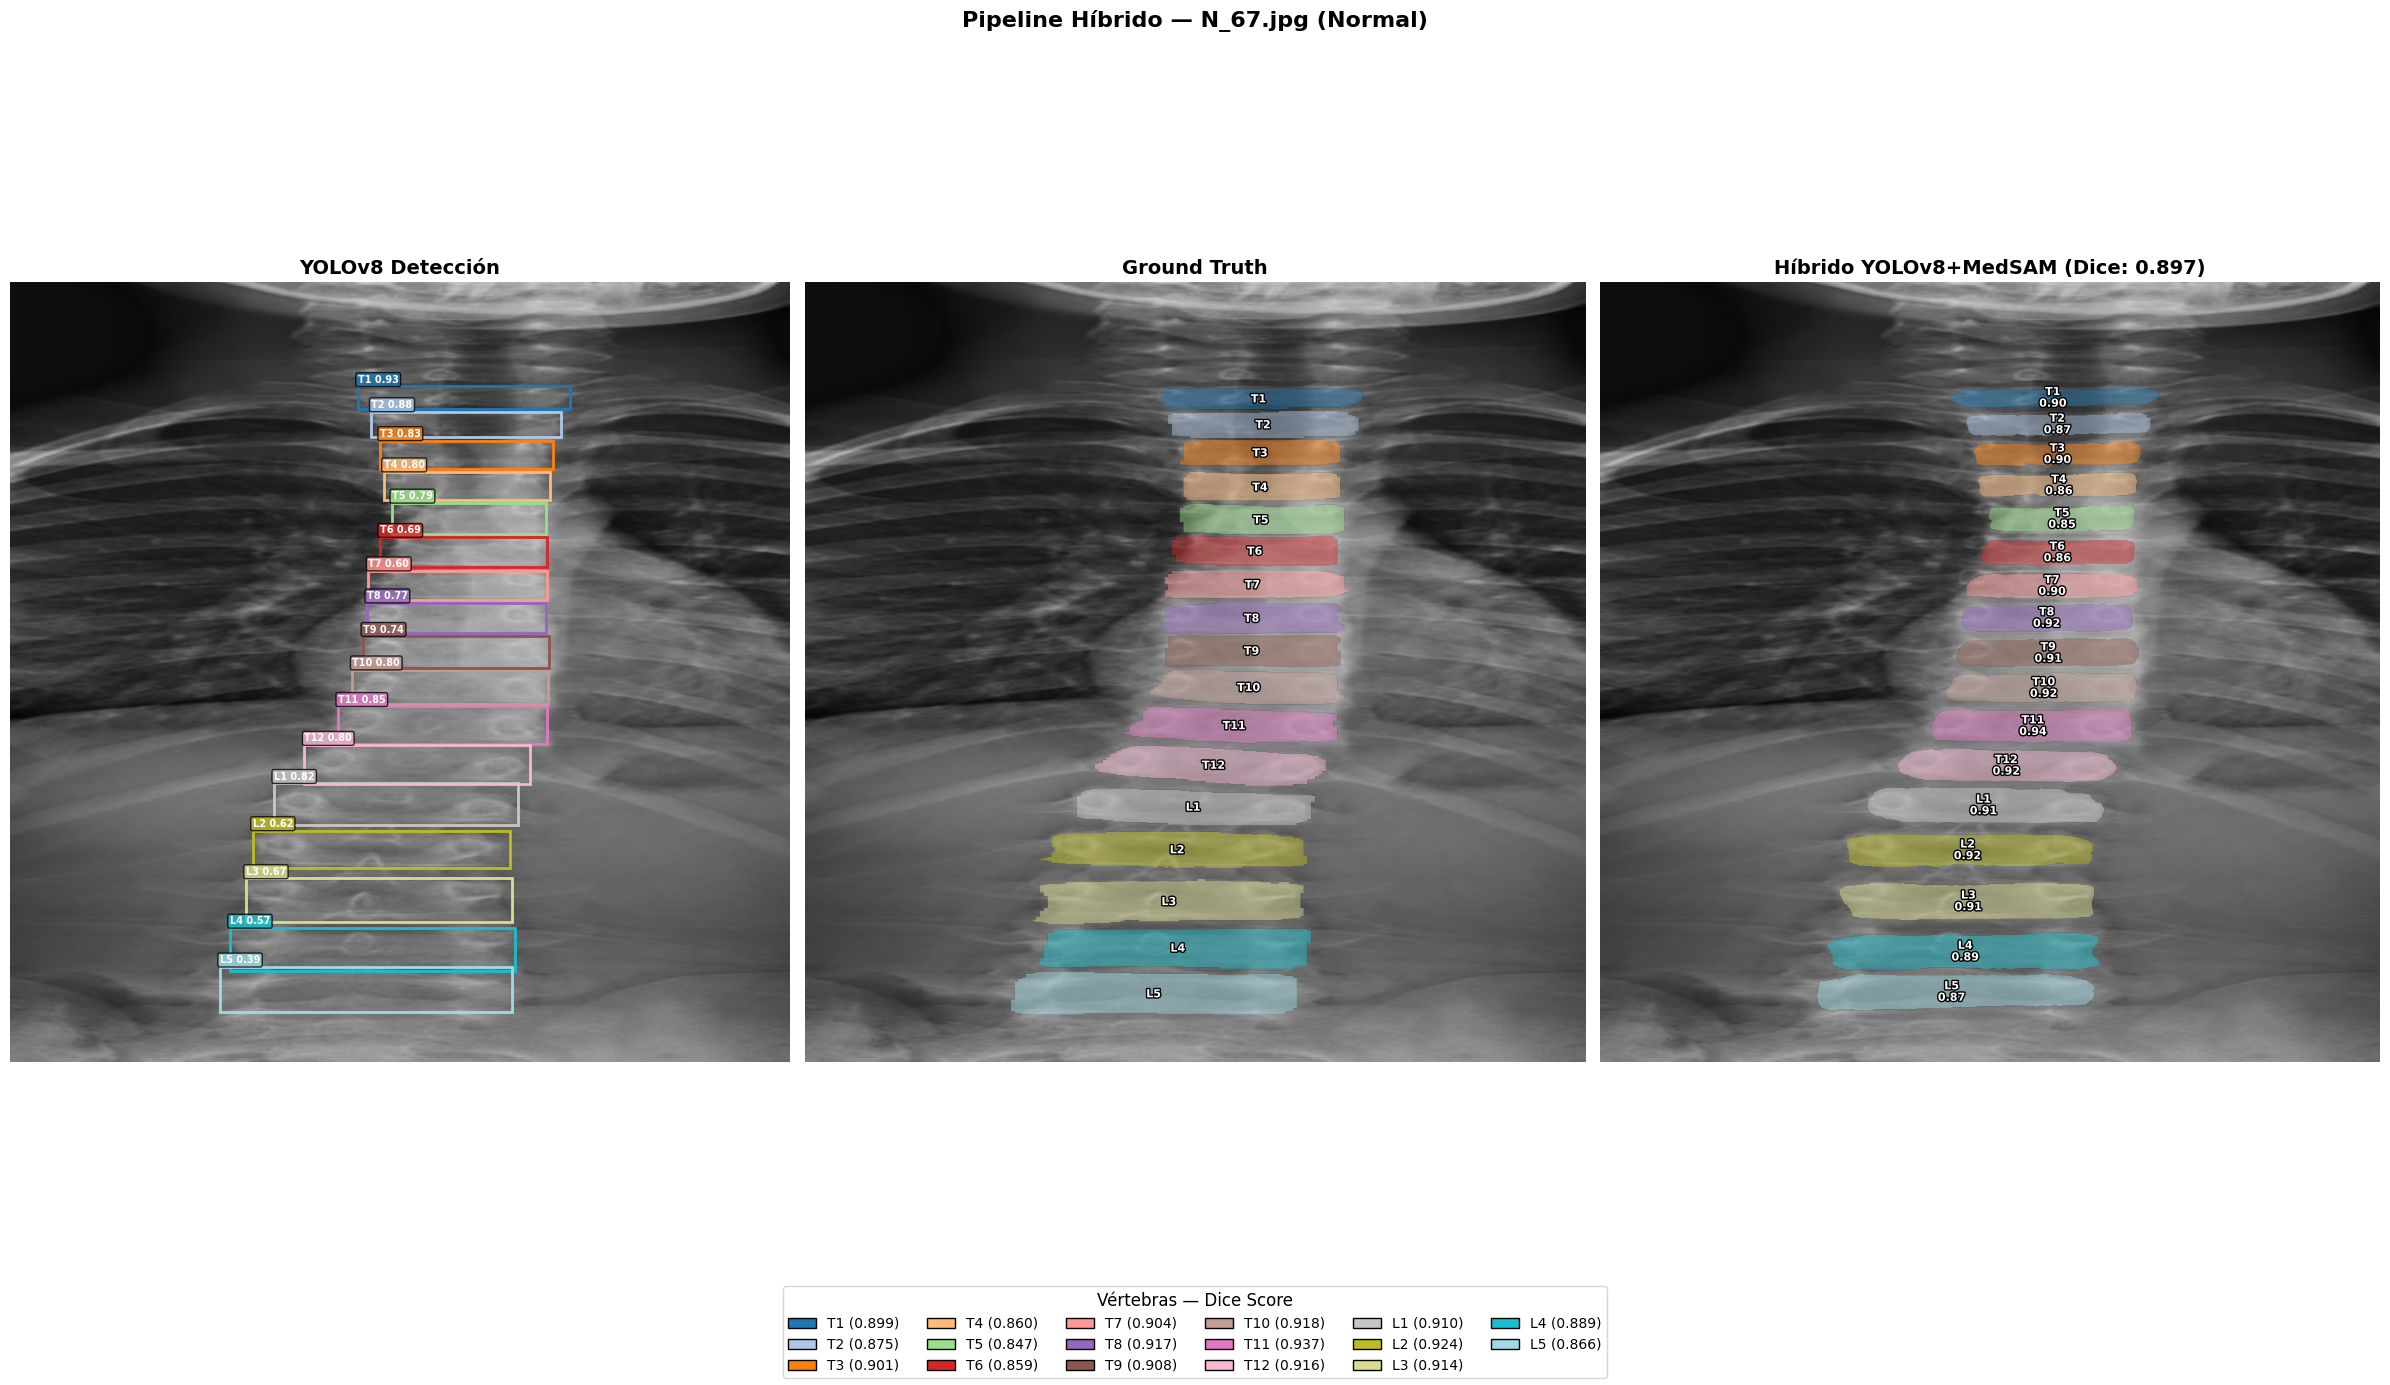


  Dice — N_67.jpg (Normal)
    T1: 0.8988 █████████████████
    T2: 0.8747 █████████████████
   T11: 0.9371 ██████████████████
    T3: 0.9007 ██████████████████
    L1: 0.9095 ██████████████████
    T4: 0.8598 █████████████████
   T12: 0.9158 ██████████████████
   T10: 0.9178 ██████████████████
    T5: 0.8472 ████████████████
    T8: 0.9166 ██████████████████
    T9: 0.9079 ██████████████████
    T6: 0.8593 █████████████████
    L3: 0.9135 ██████████████████
    L2: 0.9244 ██████████████████
    T7: 0.9040 ██████████████████
    L4: 0.8890 █████████████████
    L5: 0.8662 █████████████████
────────────────────────────────────────
  MEAN: 0.8966


In [10]:
cmap_colors = plt.cm.get_cmap('tab20', NUM_CLASSES)
COLORS = [cmap_colors(i)[:3] for i in range(NUM_CLASSES)]

def visualize_hybrid(image, predictions, gt_mask=None, title=''):
    img_1024 = cv2.resize(image, (1024, 1024))
    h, w = 1024, 1024
    ts = dict(fontsize=8, fontweight='bold', color='white', ha='center', va='center',
              path_effects=[pe.withStroke(linewidth=2, foreground='black')])

    fig, axes = plt.subplots(1, 3, figsize=(24, 14))

    # ── Panel 1: YOLOv8 Detección ──
    axes[0].imshow(img_1024)
    for cn, data in predictions.items():
        cid = CLASS_NAMES.index(cn)
        x1,y1,x2,y2 = data['bbox']
        col = COLORS[cid]
        axes[0].add_patch(plt.Rectangle((x1,y1),x2-x1,y2-y1,lw=2,ec=col,fc='none'))
        axes[0].text(x1,y1-5,f'{cn} {data["conf"]:.2f}',fontsize=7,color='white',
                     fontweight='bold',bbox=dict(boxstyle='round,pad=0.2',facecolor=col,alpha=0.8))
    axes[0].set_title('YOLOv8 Detección',fontsize=14,fontweight='bold')
    axes[0].axis('off')

    # ── Panel 2: Ground Truth ──
    gt_ov = np.zeros((h,w,4),dtype=np.float32)
    if gt_mask is not None:
        gt_r = cv2.resize(gt_mask,(1024,1024),interpolation=cv2.INTER_NEAREST)
        for cid in range(1, NUM_CLASSES+1):
            m = gt_r == cid
            if m.sum()<50: continue
            col = COLORS[cid-1]
            gt_ov[m,0]=col[0]; gt_ov[m,1]=col[1]; gt_ov[m,2]=col[2]; gt_ov[m,3]=0.45
            ys,xs = np.where(m)
            axes[1].text(int(xs.mean()),int(ys.mean()),CLASS_NAMES[cid-1],**ts)
    axes[1].imshow(img_1024); axes[1].imshow(gt_ov)
    axes[1].set_title('Ground Truth',fontsize=14,fontweight='bold')
    axes[1].axis('off')

    # ── Panel 3: Hybrid Prediction ──
    pr_ov = np.zeros((h,w,4),dtype=np.float32)
    dice_scores = {}
    for cn, data in predictions.items():
        cid = CLASS_NAMES.index(cn)
        col = COLORS[cid]
        m = data['mask'] > 0
        pr_ov[m,0]=col[0]; pr_ov[m,1]=col[1]; pr_ov[m,2]=col[2]; pr_ov[m,3]=0.45
        # Compute dice vs GT
        if gt_mask is not None:
            gt_r = cv2.resize(gt_mask,(1024,1024),interpolation=cv2.INTER_NEAREST)
            gt_bin = (gt_r == (cid+1)).astype(np.uint8)
            dice_scores[cn] = compute_dice(data['mask'], gt_bin)
        ys,xs = np.where(m)
        if len(xs)>0:
            d = dice_scores.get(cn, 0)
            axes[2].text(int(xs.mean()),int(ys.mean()),f'{cn}\n{d:.2f}',**ts)

    axes[2].imshow(img_1024); axes[2].imshow(pr_ov)
    md_val = np.mean(list(dice_scores.values())) if dice_scores else 0
    axes[2].set_title(f'Híbrido YOLOv8+MedSAM (Dice: {md_val:.3f})',fontsize=14,fontweight='bold')
    axes[2].axis('off')

    # ── Leyenda ──
    lp = [Patch(facecolor=COLORS[i],edgecolor='k',
                label=f'{CLASS_NAMES[i]} ({dice_scores.get(CLASS_NAMES[i],0):.3f})')
          for i in range(NUM_CLASSES) if CLASS_NAMES[i] in predictions]
    fig.legend(handles=lp,loc='lower center',ncol=6,fontsize=10,frameon=True,
              title='Vértebras — Dice Score',title_fontsize=12)
    fig.suptitle(f'Pipeline Híbrido — {title}',fontsize=16,fontweight='bold',y=0.98)
    plt.tight_layout(rect=[0,0.08,1,0.96]); plt.show()

    # Tabla
    if dice_scores:
        print(f'\n{"="*40}')
        print(f'  Dice — {title}')
        print(f'{"="*40}')
        for cn,d in dice_scores.items():
            print(f'  {cn:>4s}: {d:.4f} {"█"*int(d*20)}')
        print(f'{"─"*40}\n  MEAN: {md_val:.4f}')

# ── Visualizar 3 imágenes de test ──
for i in range(min(3, len(test_df))):
    row = test_df.iloc[i]
    img, gt = load_image_and_mask(row)
    preds = hybrid_predict(img, best_yolo, model_sam, processor)
    visualize_hybrid(img, preds, gt, title=f'{row["imagen"]} ({row[COL_GRUPO]})')

## 8 — Guardar Resultados

In [11]:
# ── Guardar pesos YOLOv8 en HuggingFace ──
yolo_best = str(WORK_DIR / 'yolo_runs' / 'vertebra_detect' / 'weights' / 'best.pt')

from huggingface_hub import HfApi
api = HfApi()

# Subir YOLOv8
api.upload_file(
    path_or_fileobj=yolo_best,
    path_in_repo='yolov8_vertebra_detect.pt',
    repo_id='javiercamilogarcia/submissions',
    repo_type='dataset',
    token=''  # ← reemplazar
)
print('✔ YOLOv8 subido a HuggingFace')
print('✔ MedSAM ya está en HuggingFace (medsam_spine_finetuned.pth)')

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

✔ YOLOv8 subido a HuggingFace
✔ MedSAM ya está en HuggingFace (medsam_spine_finetuned.pth)


## 9 — Comparativa y Próximos Pasos

### Comparativa de Modelos:
| Modelo | Identifica clase | Calidad borde | Fusiona vértebras | Necesita bbox GT |
|---|---|---|---|---|
| YOLOv8 solo | ✅ | 🔸 Regular | ❌ | ❌ |
| MedSAM solo | ❌ | ✅ Excelente | ⚠️ Sí | ✅ Sí |
| **Híbrido** | ✅ YOLOv8 | ✅ MedSAM | ❌ | ❌ |

### Próximos pasos:
1. **Ajustar confianza** — probar `conf=0.15` o `conf=0.30`
2. **Fine-tune MedSAM v3** — re-entrenar con margin=2 y subir pesos actualizados
3. **Post-procesamiento posicional** — ordenar por centroide Y ante confusiones
4. **NMS por clase** — si YOLOv8 detecta 2 T5, quedarse con la de mayor confianza
5. **Exportar a ONNX** — para despliegue en producción